In [ ]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import os
import plotly.express as px
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# step 6 create .env vars

load_dotenv()
API_URL = os.getenv('API_URL')
DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')


# step 3
'''
don't forget or later convert to vars
begin_date = 2023-03-01 
end_date = 2023-09-01
api_url = https://data-charts-api.hexlet.app/
'''

# getting data from api
registrations = requests.get(f'{API_URL}/registrations', params={'begin': DATE_BEGIN, 'end': DATE_END})
visits = requests.get(f'{API_URL}/visits', params={'begin': DATE_BEGIN, 'end': DATE_END})
registrations_json = registrations.json()
visits_json = visits.json()

registrations_df = pd.DataFrame(registrations_json)
visits_df = pd.DataFrame(visits_json)

# processing visits
visits_df = visits_df[~visits_df['user_agent'].str.contains('bot', case=False, na=False)]
visits_df['datetime'] = pd.to_datetime(visits_df['datetime'])
visits_df = visits_df.drop_duplicates(subset='visit_id', keep='last')
visits_df['date_group'] = visits_df['datetime'].dt.date
visits_aggr = (visits_df.groupby(['date_group', 'platform'], as_index=False).agg(visits=('visit_id', 'count')))


# processing registrations
registrations_df['datetime'] = pd.to_datetime(registrations_df['datetime'])
registrations_df['date_group'] = registrations_df['datetime'].dt.date
registrations_aggr = (registrations_df.groupby(['date_group', 'platform'], as_index=False).agg(registrations=('user_id', 'count')))

# result df + conversion
result_df = (pd.merge(visits_aggr, registrations_aggr, on=['date_group', 'platform'], how='outer'))
result_df['visits'] = result_df['visits'].astype(int)
result_df['registrations'] = result_df['registrations'].astype(int)
result_df['conversion'] = np.where(result_df['visits'] > 0, (result_df['registrations'] / result_df['visits']) * 100, 0)

result_df = result_df.sort_values(['date_group', 'platform']).reset_index(drop=True)

result_df.to_json('./conversion.json')



In [ ]:
# step 4

# convert csv to df
ads_df = pd.read_csv('./ads.csv')
ads_df['datetime'] = pd.to_datetime(ads_df['date'])
ads_df['date_group'] = ads_df['datetime'].dt.date

ads_aggr = ads_df.groupby('date_group', as_index=False).agg(cost=('cost', 'sum'), utm_campaign=('utm_campaign', 'first'))
result_df_prep = result_df.groupby('date_group', as_index=False).agg(visits=('visits', 'sum'), registrations=('registrations', 'sum'))

# merge and fill data
ads_result_df = pd.merge(result_df_prep, ads_aggr, on='date_group', how='left')

ads_result_df['cost'] = ads_result_df['cost'].fillna(0)
ads_result_df['utm_campaign'] = ads_result_df['utm_campaign'].fillna('none')
ads_result_df = ads_result_df.sort_values('date_group')

ads_result_df.to_json('./ads.json')


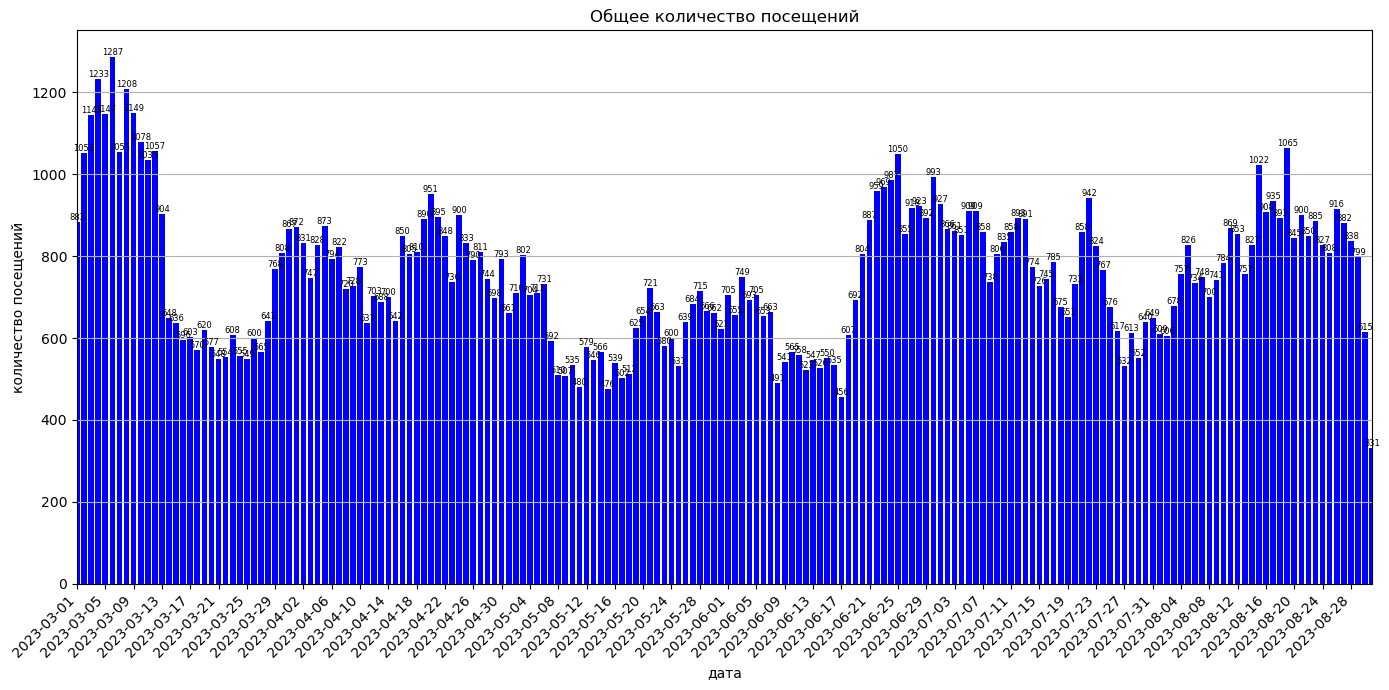

In [3]:
# step 5
os.makedirs('./charts', exist_ok=True)
charts_dir = './charts'
figsize_def = (14, 7)

ads_result_df['date_group'] = pd.to_datetime(ads_result_df['date_group'])
result_df['date_group'] = pd.to_datetime(result_df['date_group'])

# plot 1 total visits

grouped_visits = ads_result_df.groupby('date_group')['visits'].sum().reset_index()

plt.figure(figsize=figsize_def)
bars = plt.bar(grouped_visits['date_group'], grouped_visits['visits'], color='blue', width=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, '%d' % int(height), ha='center', va='bottom', fontsize=6)
plt.title('Общее количество посещений')
plt.xlabel('дата')
plt.ylabel('количество посещений')
plt.xticks(grouped_visits['date_group'][::4], rotation=45, ha='right')
plt.xlim(min(grouped_visits['date_group']), max(grouped_visits['date_group']))
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'total_visits.png'))
plt.show()

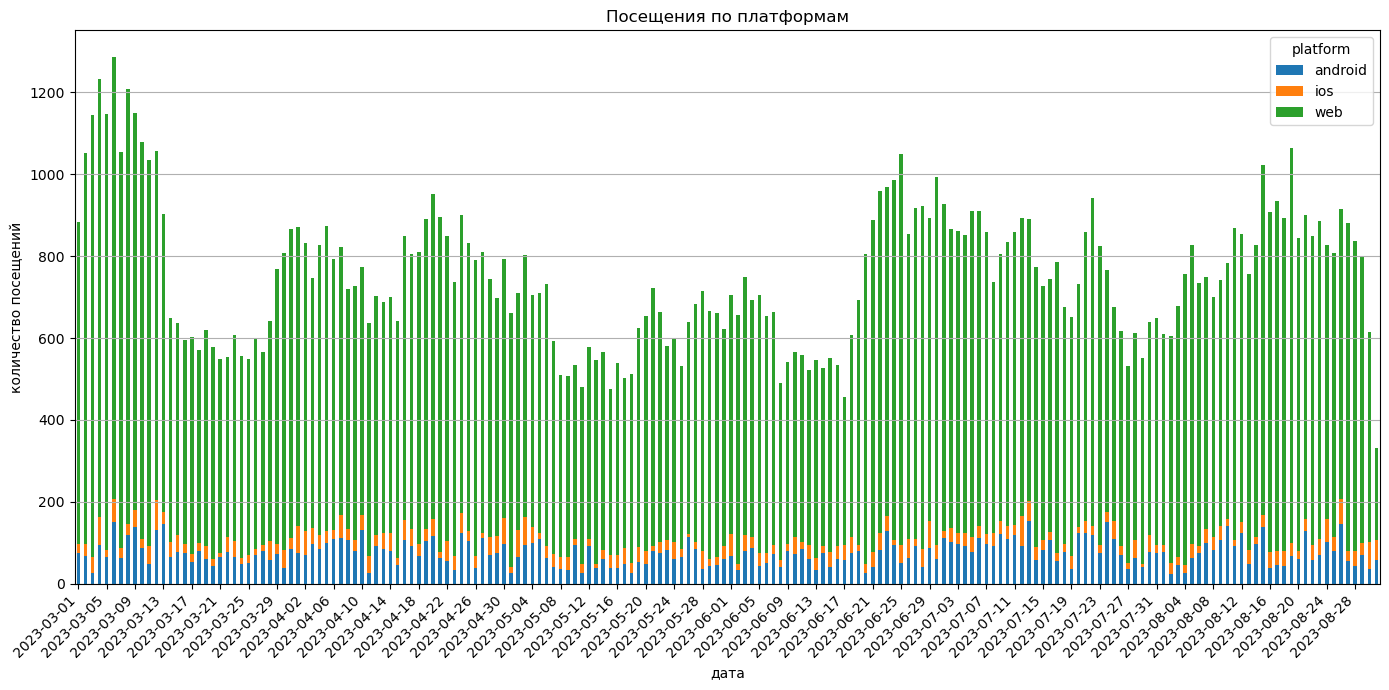

In [4]:
# plot 2 visits by platform

pivot_v = result_df.pivot_table(values='visits', index='date_group', columns='platform', aggfunc='sum', fill_value=0)
pivot_v.index = pivot_v.index.strftime('%Y-%m-%d')

fig, ax = plt.subplots(figsize=figsize_def)
pivot_v.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Посещения по платформам')
ax.set_xlabel('дата')
ax.set_ylabel('количество посещений')
ax.set_xticks(range(0, len(pivot_v.index), 4))
ax.set_xticklabels(pivot_v.index[::4], rotation=45, ha='right')
ax.set_xlim(-0.5, len(pivot_v.index) - 0.5)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'visits_by_platform.png'))
plt.show()
        

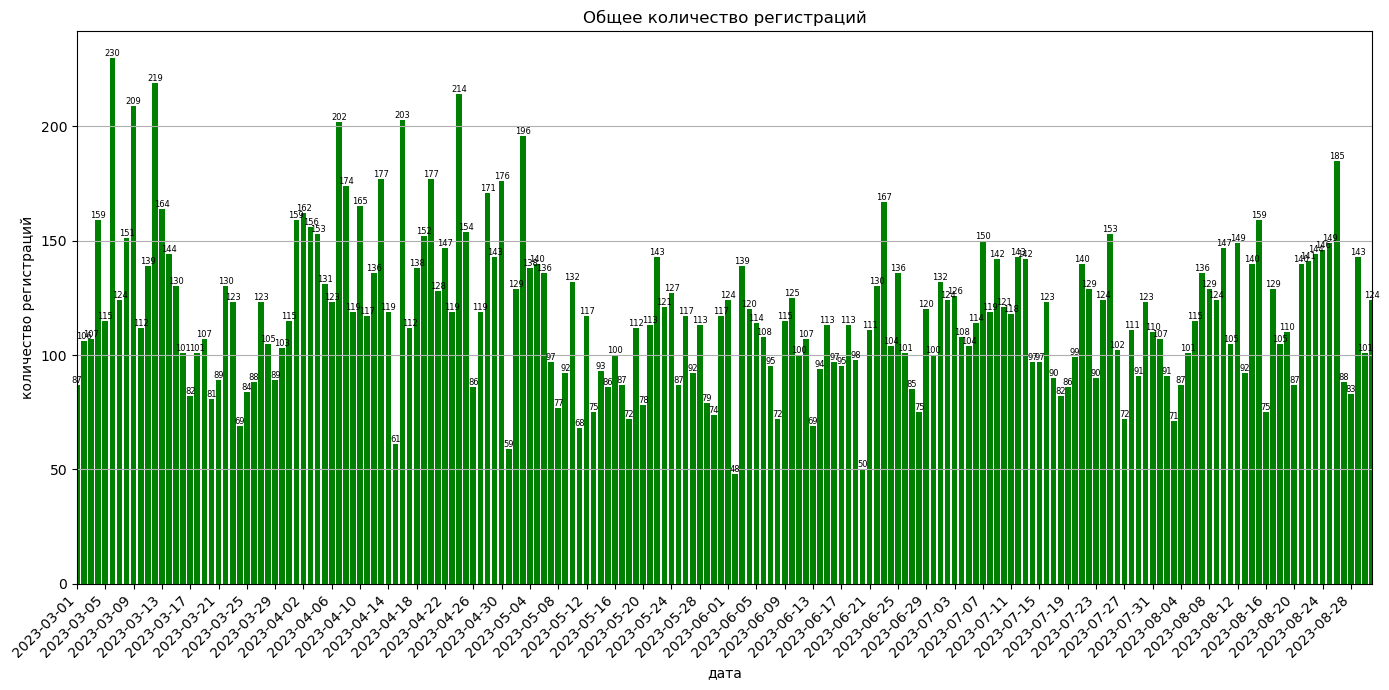

In [5]:
# plot 3 total registrations
grouped_reg = ads_result_df.groupby('date_group')['registrations'].sum().reset_index()

plt.figure(figsize=figsize_def)
bars = plt.bar(grouped_reg['date_group'], grouped_reg['registrations'], color='green', width=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, '%d' % int(height), ha='center', va='bottom', fontsize=6)
plt.title('Общее количество регистраций')
plt.ylabel("количество регистраций")
plt.xlabel('дата')
plt.xticks(grouped_reg['date_group'][::4], rotation=45, ha='right')
plt.xlim(min(grouped_reg['date_group']), max(grouped_reg['date_group']))
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'total_registrations.png'))
plt.show()

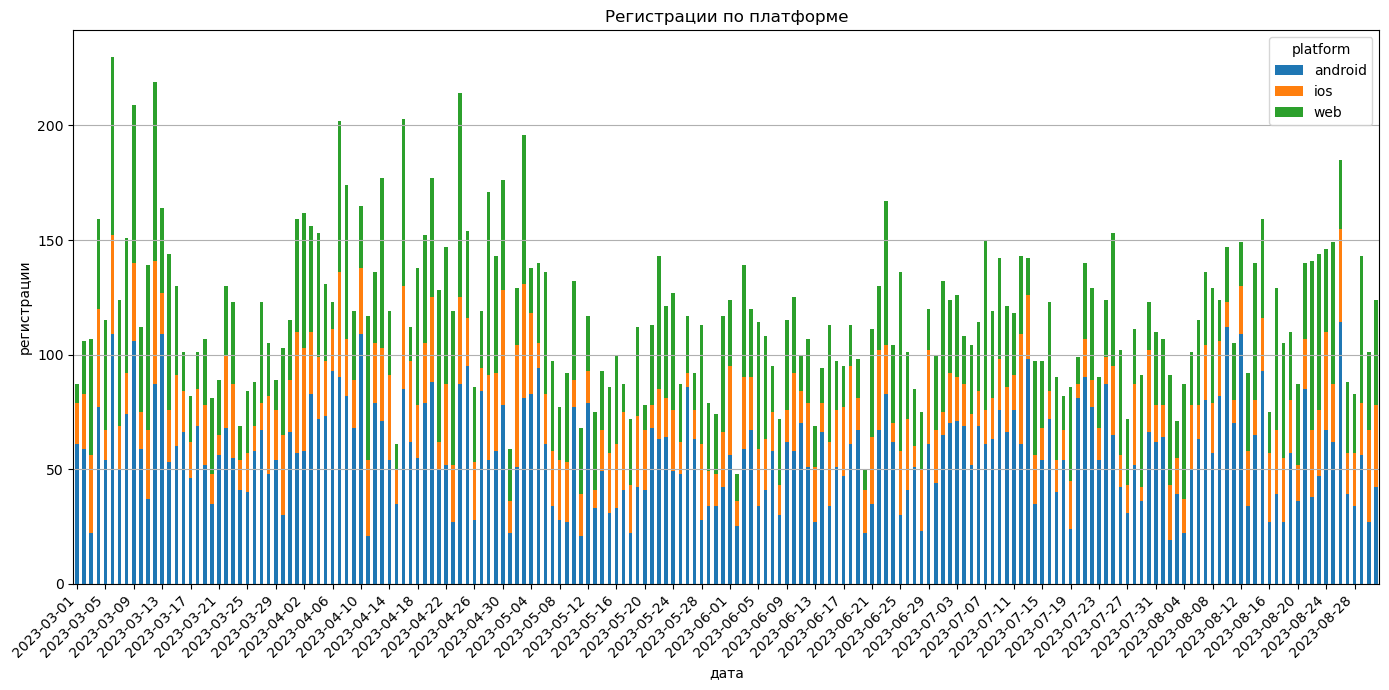

In [6]:
# plot 4 registrations by platfrom

pivot_r = result_df.pivot_table(values='registrations', index='date_group', columns='platform', aggfunc='sum', fill_value=0)
pivot_r.index = pivot_r.index.strftime('%Y-%m-%d')


fig, ax = plt.subplots(figsize=figsize_def)
pivot_r.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Регистрации по платформе')
ax.set_xlabel('дата')
ax.set_ylabel('регистрации')
ax.set_xticks(range(0, len(pivot_r.index), 4))
ax.set_xticklabels(pivot_r.index[::4], rotation=45, ha='right')
ax.set_xlim(-0.5, len(pivot_r.index) - 0.5)
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'registrations_by_platform.png'))
plt.show()

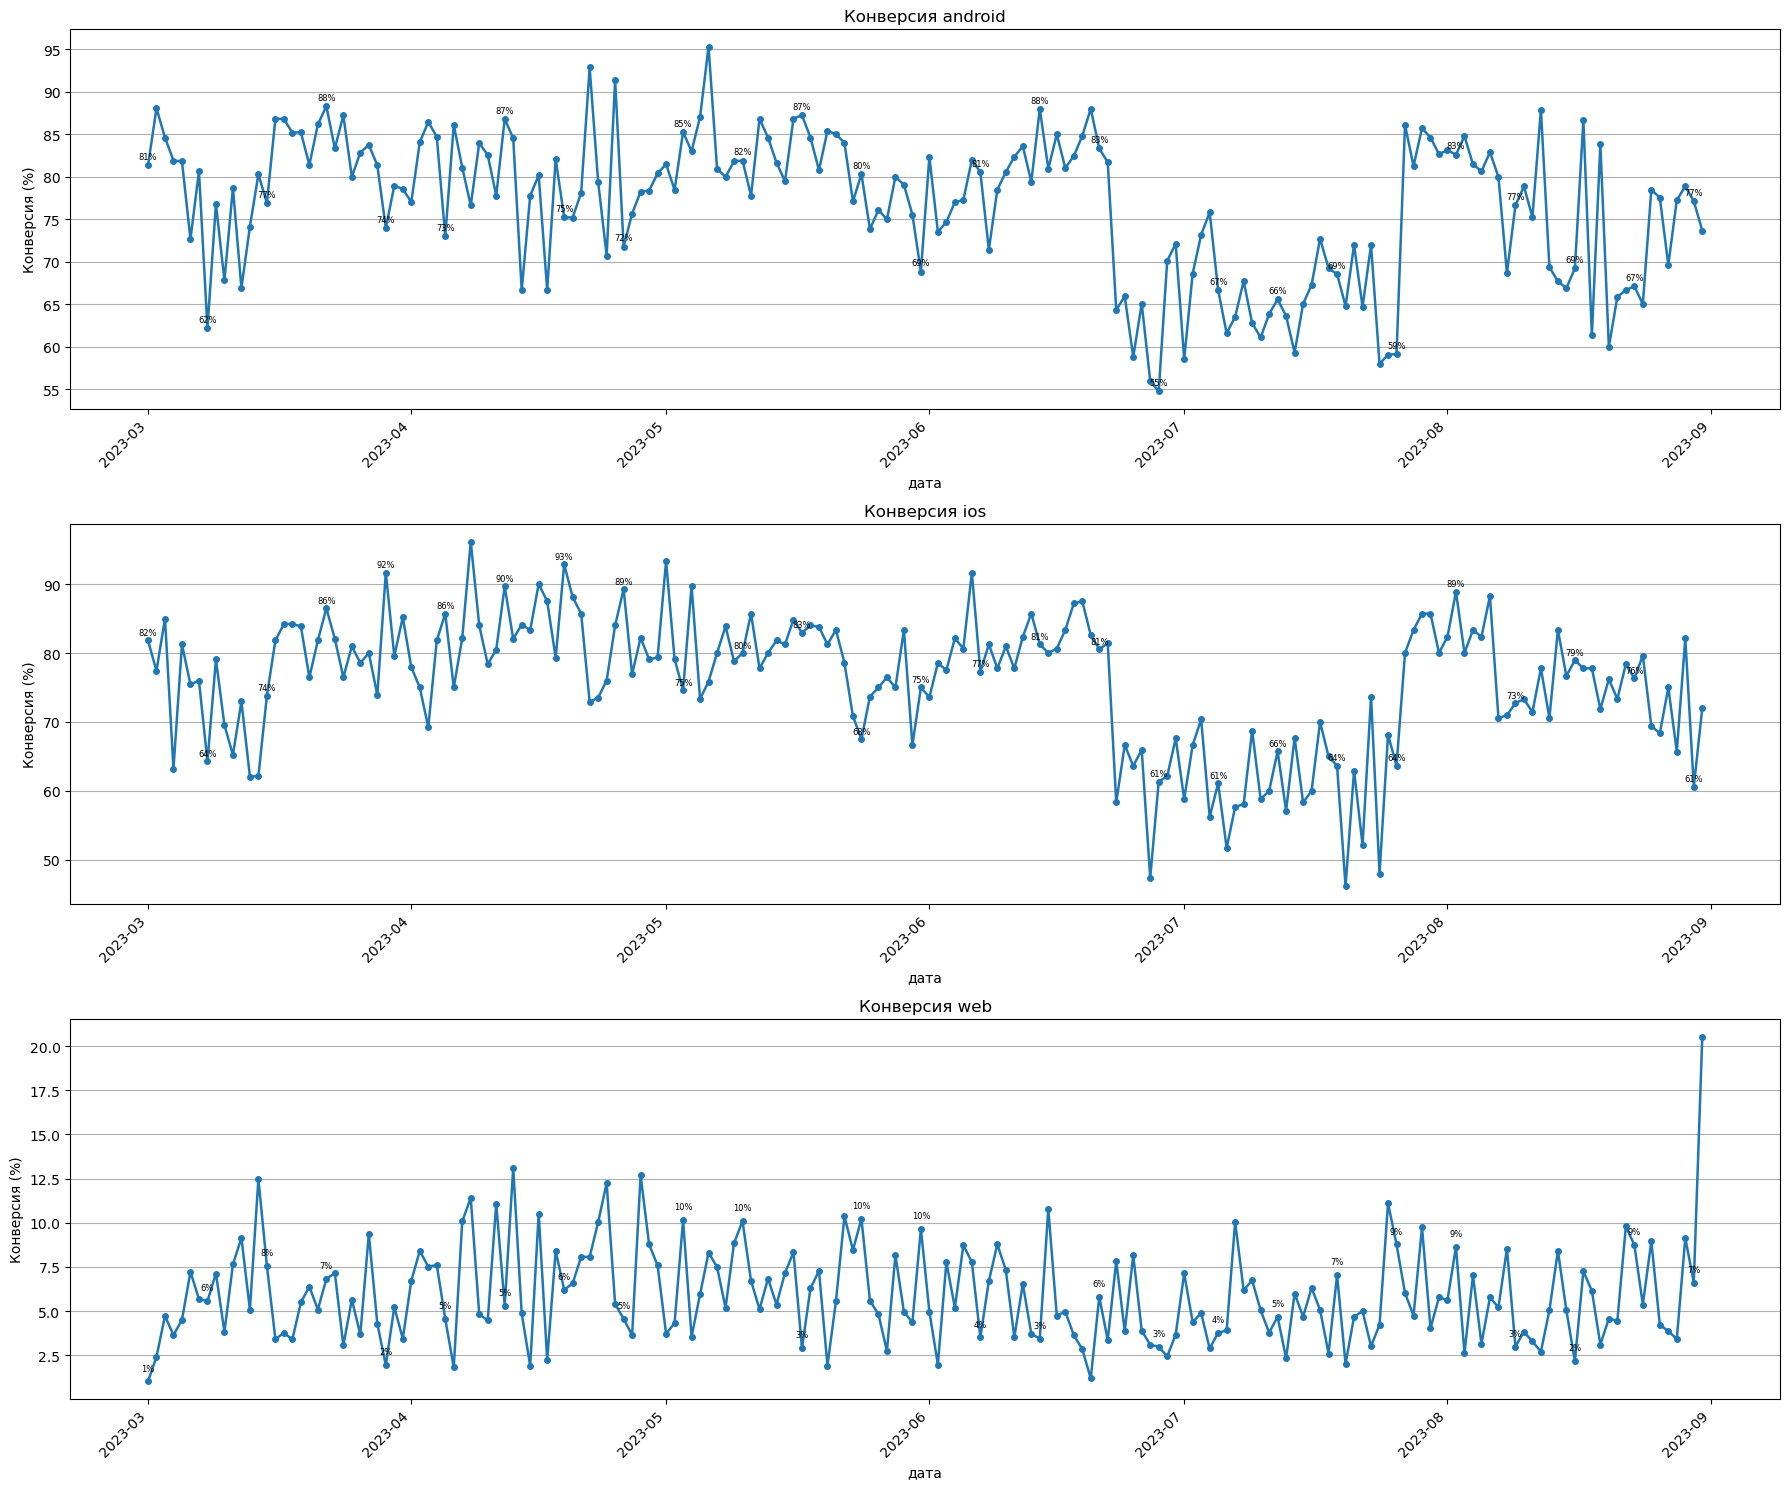

In [7]:
# plot 5 conversion by platform

fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=False)
for ax, plat in zip(axes, ['android', 'ios', 'web']):
    df_p = result_df[result_df['platform'] == plat].sort_values('date_group')
    ax.plot(df_p['date_group'], df_p['conversion'], marker='o', markersize=4, linewidth=1.8)
    for x, y in zip(df_p['date_group'].iloc[::7], df_p['conversion'].iloc[::7]):
        ax.text(x, y + 0.5, f'{y:.0f}%', ha='center', va='bottom', fontsize=6)
    ax.set_title(f'Конверсия {plat}')
    ax.set_xlabel('дата')
    ax.set_ylabel('Конверсия (%)')
    ax.grid(axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'conversion_by_platform.png'))
plt.show()

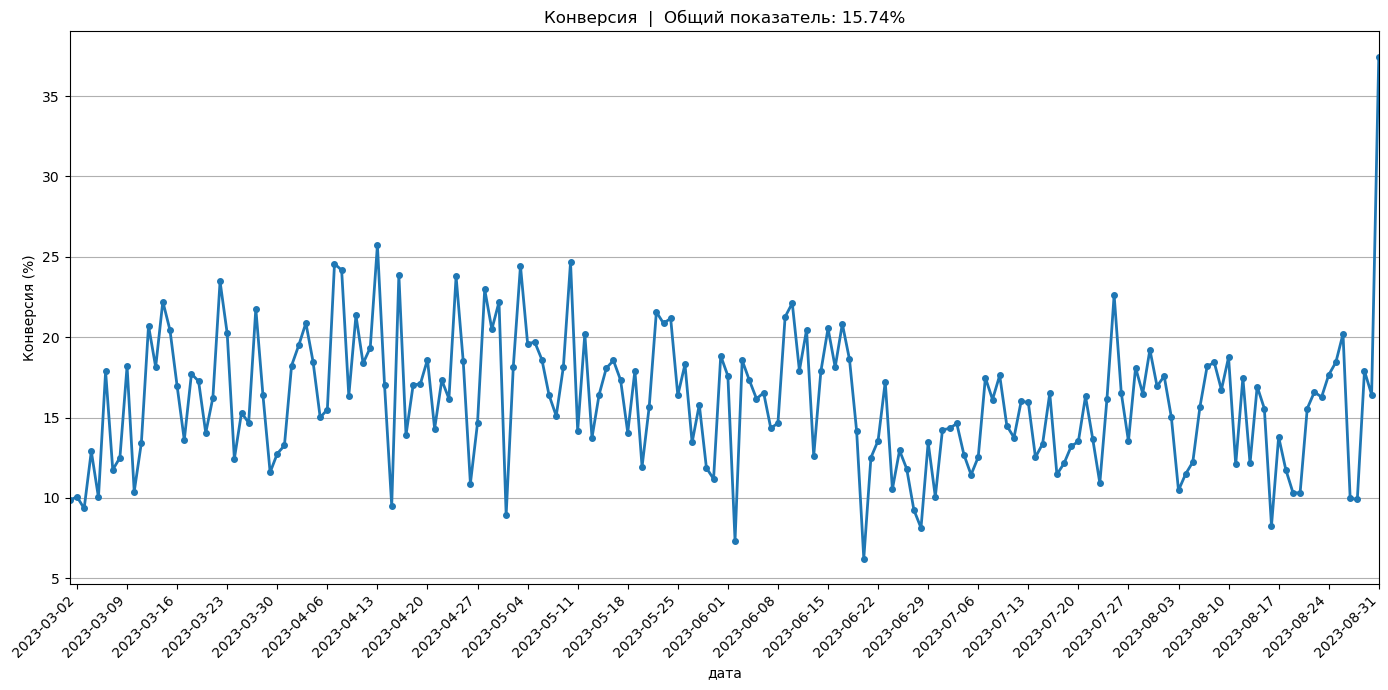

In [8]:
# plot 6 total conversion

overall_conv = ads_result_df[['date_group', 'visits', 'registrations']].copy()
overall_conv['conversion'] = (overall_conv['registrations'] / overall_conv['visits'] * 100).round(2)

total_conversion = (ads_result_df['registrations'].sum() / ads_result_df['visits'].sum() * 100).round(2)

plt.figure(figsize=figsize_def)
plt.plot(overall_conv['date_group'], overall_conv['conversion'], marker='o', markersize=4, linewidth=2)
plt.xlabel('дата')
plt.ylabel('Конверсия (%)')
plt.title(f'Конверсия  |  Общий показатель: {total_conversion}%')
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.xlim(min(overall_conv['date_group']), max(overall_conv['date_group']))
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'overall_conversion.png'))
plt.show()


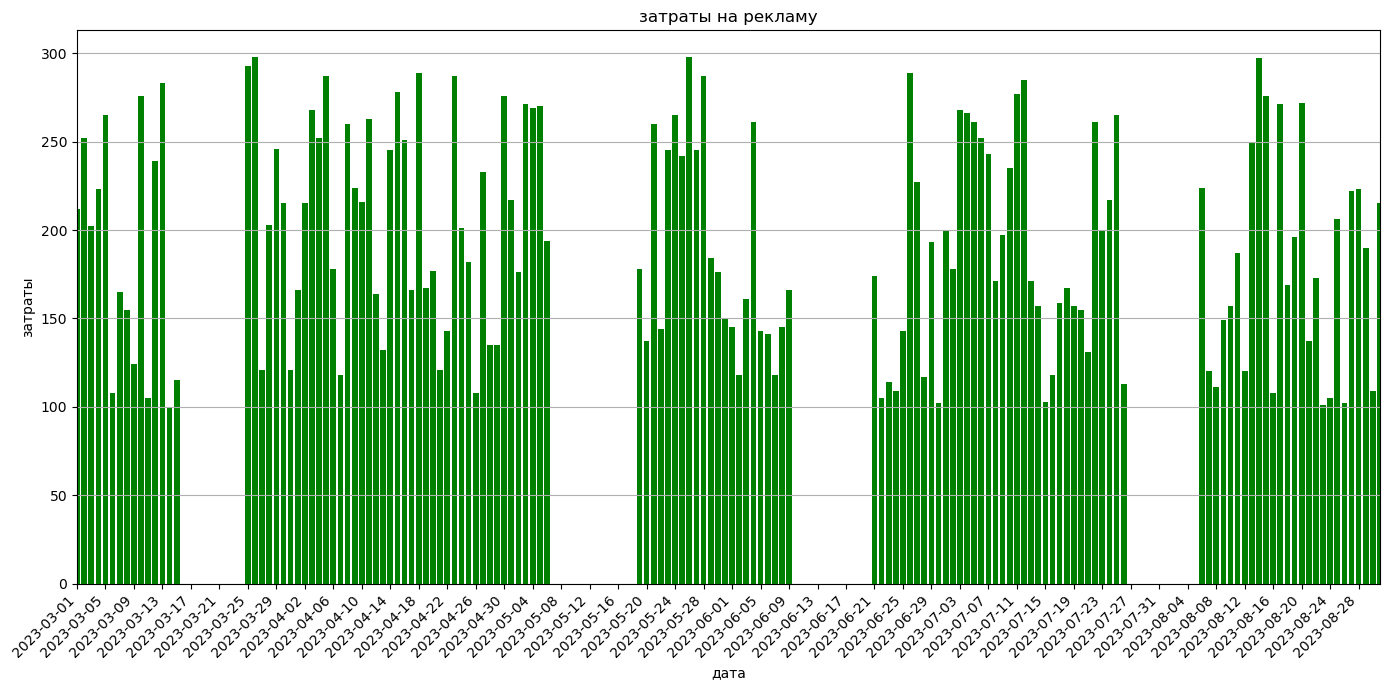

In [9]:
# plot 7 ads cost

plt.figure(figsize=figsize_def)
bars = plt.bar(ads_result_df['date_group'], ads_result_df['cost'], color='green', width=0.8)
plt.xlabel('дата')
plt.ylabel('затраты')
plt.title('затраты на рекламу')
plt.xticks(ads_result_df['date_group'][::4], rotation=45, ha='right')
plt.xlim(min(ads_result_df['date_group']), max(ads_result_df['date_group']))
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'ad_cost.png'))
plt.show()

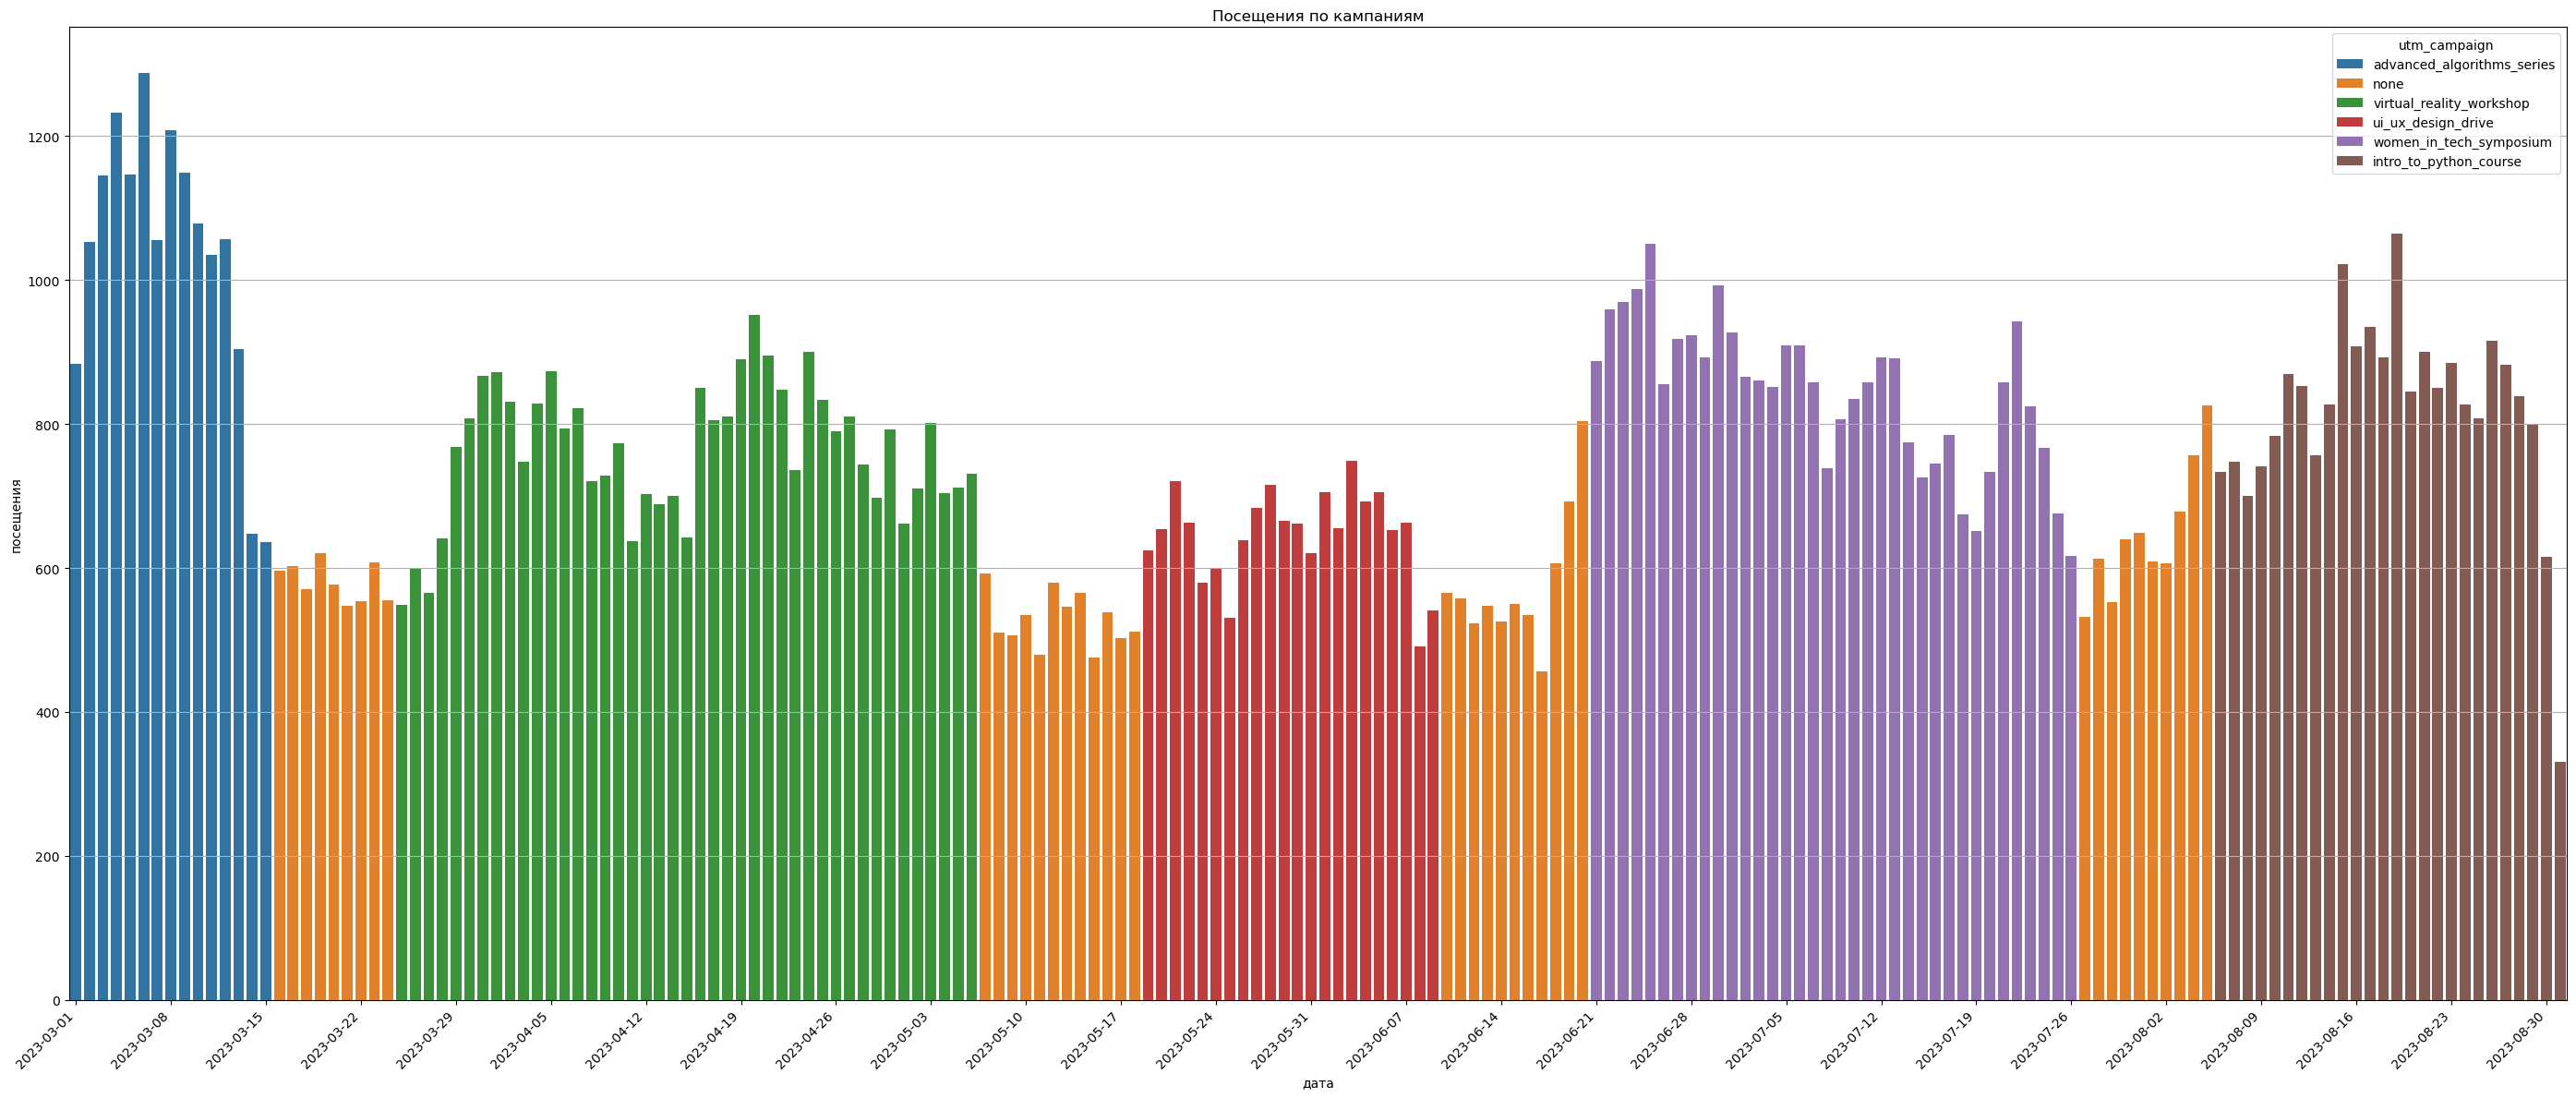

In [10]:
# plot 8 visits with campaign

campaigns = ads_result_df['utm_campaign'].unique()
palette = sns.color_palette('tab10', len(campaigns))
camp_colors = dict(zip(campaigns, palette))

fig, ax = plt.subplots(figsize=(28, 12))
sns.barplot(data=ads_result_df, x='date_group', y='visits', hue='utm_campaign', ax=ax)
ax.set_title('Посещения по кампаниям')
ax.set_xlabel('дата')
ax.set_ylabel('посещения')
ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(ticks[::7])
ax.set_xticklabels(labels[::7], rotation=45, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'visits_by_campaign.png'))
plt.show()


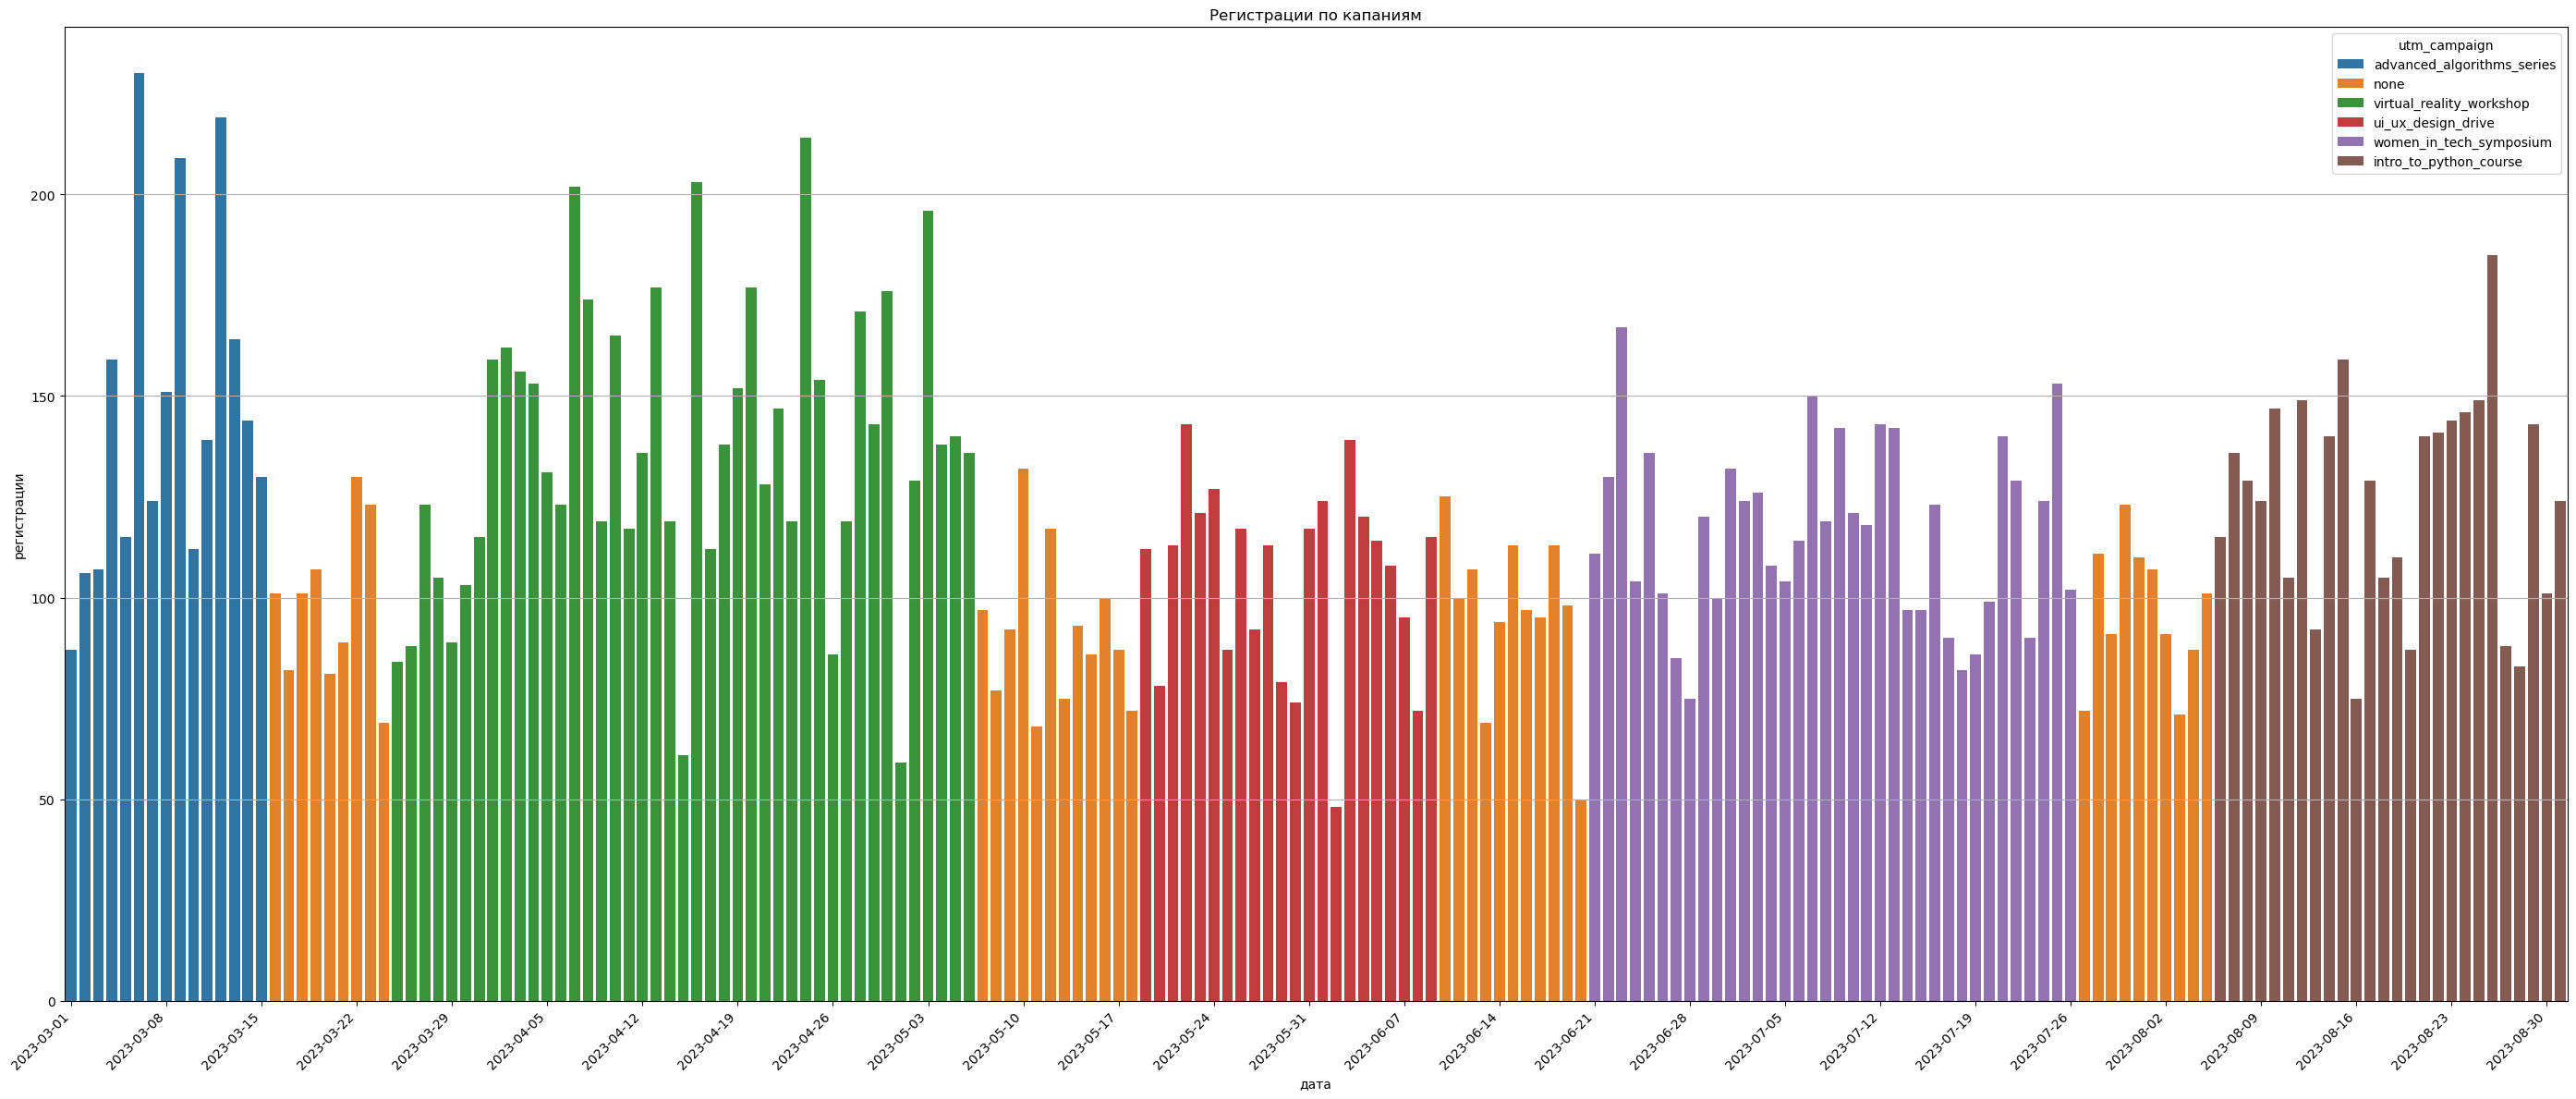

In [11]:
#plot 9 registrations with campaign

fig, ax = plt.subplots(figsize=(28, 12))
sns.barplot(data=ads_result_df, x='date_group', y='registrations', hue='utm_campaign', ax=ax)
ax.set_title('Регистрации по капаниям')
ax.set_xlabel('дата')
ax.set_ylabel('регистрации')
ticks = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(ticks[::7])
ax.set_xticklabels(labels[::7], rotation=45, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'registrations_by_campaign.png'))
plt.show()